# EDA — Paso 3: Enriquecimiento con `previous_application.csv`

**Objetivo:** Traer información de los préstamos previos internos de Home Credit hacia `application_train`.

En este Paso 3 vamos a:
1. Explorar `previous_application.csv` (solicitudes anteriores en Home Credit)
2. Analizar estados de contrato, tasas de aprobación/rechazo
3. Crear agregaciones por cliente (`SK_ID_CURR`)
4. Unir con `application_train` y analizar impacto en la TARGET

**Pregunta de negocio:** Un cliente que fue rechazado antes o que pidió montos excesivos es más riesgoso.

---
## 1. Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup listo.')

Setup listo.


---
## 2. Carga de datos

Cargamos ambas tablas. `previous_application.csv` tiene UNA fila por solicitud previa del cliente en Home Credit.

**Pregunta de negocio:** Un cliente con muchas solicitudes rechazadas es más riesgoso.

In [22]:
app_train = pd.read_csv('../data/raw/application_train.csv')
prev = pd.read_csv('../data/raw/previous_application.csv')

print('=== application_train ===')
print(f'Filas:    {app_train.shape[0]:,}')
print(f'Columnas: {app_train.shape[1]}')
print(f'IDs:      {app_train["SK_ID_CURR"].nunique():,}')
print()
print('=== previous_application ===')
print(f'Filas:    {prev.shape[0]:,}')
print(f'Columnas: {prev.shape[1]}')
print(f'IDs:      {prev["SK_ID_CURR"].nunique():,}')

=== application_train ===
Filas:    307,511
Columnas: 122
IDs:      307,511

=== previous_application ===
Filas:    1,670,214
Columnas: 37
IDs:      338,857


In [23]:
# Cuántas solicitudes previas por cliente
prev_per_client = prev.groupby('SK_ID_CURR').size()

print('Solicitudes previas por cliente:')
print(prev_per_client.describe())
print(f'\nClientes sin solicitud previa: {app_train["SK_ID_CURR"].nunique() - prev["SK_ID_CURR"].nunique():,}')
print(f'Clientes con solicitud previa: {prev["SK_ID_CURR"].nunique():,}')

Solicitudes previas por cliente:
count   338857.0000
mean         4.9290
std          4.2207
min          1.0000
25%          2.0000
50%          4.0000
75%          7.0000
max         77.0000
dtype: float64

Clientes sin solicitud previa: -31,346
Clientes con solicitud previa: 338,857


In [24]:
prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.4300,17145.0000,17145.0000,0.0000,17145.0000,SATURDAY,15,Y,1,0.0000,0.1828,0.8673,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0000,middle,POS mobile with interest,365243.0000,-42.0000,300.0000,-42.0000,-37.0000,0.0000
1,2802425,108129,Cash loans,25188.6150,607500.0000,679671.0000,NaN,607500.0000,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0000,low_action,Cash X-Sell: low,365243.0000,-134.0000,916.0000,365243.0000,365243.0000,1.0000
2,2523466,122040,Cash loans,15060.7350,112500.0000,136444.5000,NaN,112500.0000,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,high,Cash X-Sell: high,365243.0000,-271.0000,59.0000,365243.0000,365243.0000,1.0000
3,2819243,176158,Cash loans,47041.3350,450000.0000,470790.0000,NaN,450000.0000,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,middle,Cash X-Sell: middle,365243.0000,-482.0000,-152.0000,-182.0000,-177.0000,1.0000
4,1784265,202054,Cash loans,31924.3950,337500.0000,404055.0000,NaN,337500.0000,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0000,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Estructura y calidad

In [25]:
prev.info()

<class 'pandas.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  str    
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  str    
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  str    
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-null   float6

In [26]:
prev.describe()

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1670214.0000,1670214.0000,1297979.0000,1670214.0000,1670213.0000,774370.0000,1284699.0000,1670214.0000,1670214.0000,774370.0000,5951.0000,5951.0000,1670214.0000,1670214.0000,1297984.0000,997149.0000,997149.0000,997149.0000,997149.0000,997149.0000,997149.0000
mean,1923089.1353,278357.1741,15955.1207,175233.8604,196114.0212,6697.4021,227847.2793,12.4842,0.9965,0.0796,0.1884,0.7735,-880.6797,313.9511,16.0541,342209.8550,13826.2693,33767.7741,76582.4031,81992.3438,0.3326
std,532597.9587,102814.8238,14782.1373,292779.7624,318574.6165,20921.4954,315396.5579,3.3340,0.0593,0.1078,0.0877,0.1009,779.0997,7127.4435,14.5673,88916.1158,72444.8697,106857.0348,149647.4151,153303.5167,0.4711
min,1000001.0000,100001.0000,0.0000,0.0000,0.0000,-0.9000,0.0000,0.0000,0.0000,-0.0000,0.0348,0.3732,-2922.0000,-1.0000,0.0000,-2922.0000,-2892.0000,-2801.0000,-2889.0000,-2874.0000,0.0000
25%,1461857.2500,189329.0000,6321.7800,18720.0000,24160.5000,0.0000,50841.0000,10.0000,1.0000,0.0000,0.1607,0.7156,-1300.0000,-1.0000,6.0000,365243.0000,-1628.0000,-1242.0000,-1314.0000,-1270.0000,0.0000
50%,1923110.5000,278714.5000,11250.0000,71046.0000,80541.0000,1638.0000,112320.0000,12.0000,1.0000,0.0516,0.1891,0.8351,-581.0000,3.0000,12.0000,365243.0000,-831.0000,-361.0000,-537.0000,-499.0000,0.0000
75%,2384279.7500,367514.0000,20658.4200,180360.0000,216418.5000,7740.0000,234000.0000,15.0000,1.0000,0.1089,0.1933,0.8525,-280.0000,82.0000,24.0000,365243.0000,-411.0000,129.0000,-74.0000,-44.0000,1.0000
max,2845382.0000,456255.0000,418058.1450,6905160.0000,6905160.0000,3060045.0000,6905160.0000,23.0000,1.0000,1.0000,1.0000,1.0000,-1.0000,4000000.0000,84.0000,365243.0000,365243.0000,365243.0000,365243.0000,365243.0000,1.0000


In [27]:
# Nulos
nulls = prev.isnull().sum()
nulls_pct = (nulls / len(prev) * 100).round(2)

null_df = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct}).query('nulos > 0').sort_values('pct', ascending=False)
print(f'Columnas con nulos: {len(null_df)} de {prev.shape[1]}')
null_df

Columnas con nulos: 16 de 37


,nulos,pct
RATE_INTEREST_PRIVILEGED,1664263,99.6400
RATE_INTEREST_PRIMARY,1664263,99.6400
AMT_DOWN_PAYMENT,895844,53.6400
RATE_DOWN_PAYMENT,895844,53.6400
NAME_TYPE_SUITE,820405,49.1200
DAYS_LAST_DUE,673065,40.3000
DAYS_FIRST_DRAWING,673065,40.3000
DAYS_FIRST_DUE,673065,40.3000
DAYS_TERMINATION,673065,40.3000
NFLAG_INSURED_ON_APPROVAL,673065,40.3000


---
## 4. Análisis de estados de contrato

La variable más importante de esta tabla: `NAME_CONTRACT_STATUS`.

Los estados son:
- **Approved** → Aprobado
- **Canceled** → Cancelado por el cliente
- **Refused** → Rechazado por Home Credit
- **Unused offer** → Oferta no usada

In [28]:
# Distribución de estados
print('ESTADOS DE CONTRATOS PREVIOS:')
status_counts = prev['NAME_CONTRACT_STATUS'].value_counts()
status_pct = prev['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100

for status in status_counts.index:
    print(f'  {status:20s} → {status_counts[status]:>8,} ({status_pct[status]:.1f}%)')

ESTADOS DE CONTRATOS PREVIOS:
  Approved             → 1,036,781 (62.1%)
  Canceled             →  316,319 (18.9%)
  Refused              →  290,678 (17.4%)
  Unused offer         →   26,436 (1.6%)


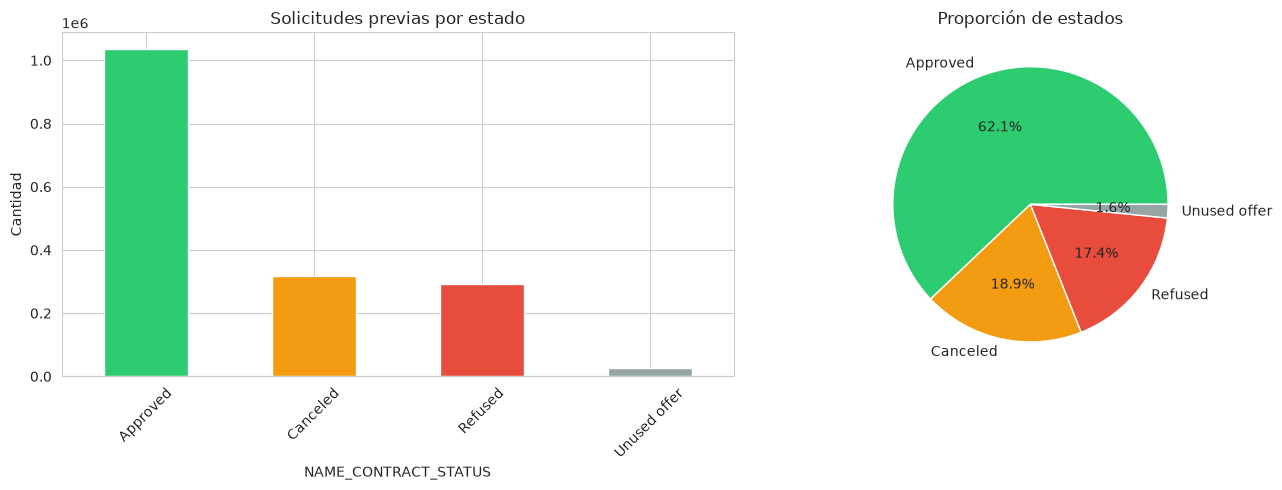

In [29]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Approved': '#2ecc71', 'Canceled': '#f39c12', 'Refused': '#e74c3c', 'Unused offer': '#95a5a6'}
status_order = prev['NAME_CONTRACT_STATUS'].value_counts().index
bar_colors = [colors.get(s, '#3498db') for s in status_order]

status_counts.plot(kind='bar', ax=axes[0], color=bar_colors)
axes[0].set_title('Solicitudes previas por estado')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

status_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=bar_colors)
axes[1].set_title('Proporción de estados')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [30]:
# Tipo de cliente vs estado
print('TIPO DE CLIENTE POR ESTADO:')
ct = pd.crosstab(prev['NAME_CLIENT_TYPE'], prev['NAME_CONTRACT_STATUS'], normalize='index') * 100
ct.round(1)

TIPO DE CLIENTE POR ESTADO:


NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
NAME_CLIENT_TYPE,,,,
New,93.3000,1.2000,4.8000,0.7000
Refreshed,71.6000,14.4000,11.1000,2.9000
Repeater,53.4000,23.7000,21.2000,1.7000
XNA,29.8000,50.3000,18.2000,1.7000


In [31]:
# Monto solicitado vs aprobado
prev['AMT_DIFF'] = prev['AMT_CREDIT'] - prev['AMT_APPLICATION']
prev['AMT_DIFF_PCT'] = (prev['AMT_CREDIT'] / prev['AMT_APPLICATION'].replace(0, np.nan) - 1) * 100

print('Diferencia entre monto solicitado y aprobado:')
print(prev.groupby('NAME_CONTRACT_STATUS')[['AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DIFF']].mean())

Diferencia entre monto solicitado y aprobado:
                      AMT_APPLICATION  AMT_CREDIT   AMT_DIFF
NAME_CONTRACT_STATUS                                        
Approved                  180567.0009 202564.1821 21997.0070
Canceled                   22730.0115  24187.0571  1457.0456
Refused                   331760.5109 371689.8412 39929.3303
Unused offer               69760.7330  69783.9908    23.2578


---
## 5. Agregaciones por cliente

Comprimimos las múltiples solicitudes previas en UNA fila por cliente.

In [32]:
# === AGREGACIONES NUMÉRICAS ===
num_agg = prev.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': ['sum', 'mean', 'max'],
    'AMT_CREDIT': ['sum', 'mean', 'max'],
    'AMT_ANNUITY': ['mean', 'max'],
    'AMT_DOWN_PAYMENT': ['sum', 'mean'],
    'DAYS_DECISION': ['mean', 'min', 'max'],
    'CNT_PAYMENT': ['mean', 'max'],
    'RATE_DOWN_PAYMENT': 'mean',
})

num_agg.columns = ['_'.join(col).strip() for col in num_agg.columns]
num_agg = num_agg.reset_index()

# Renombrar para claridad
num_agg = num_agg.rename(columns={
    'SK_ID_PREV_count': 'prev_total_applications',
    'AMT_APPLICATION_sum': 'prev_total_requested',
    'AMT_APPLICATION_mean': 'prev_avg_requested',
    'AMT_CREDIT_sum': 'prev_total_approved',
    'AMT_CREDIT_mean': 'prev_avg_approved',
    'DAYS_DECISION_mean': 'prev_avg_decision_days',
})

print(f'Clientes con agregaciones: {num_agg.shape[0]:,}')
print(f'Features generadas: {num_agg.shape[1] - 1}')
num_agg.head()

Clientes con agregaciones: 338,857
Features generadas: 17


,SK_ID_CURR,prev_total_applications,prev_total_requested,prev_avg_requested,AMT_APPLICATION_max,prev_total_approved,prev_avg_approved,AMT_CREDIT_max,AMT_ANNUITY_mean,AMT_ANNUITY_max,AMT_DOWN_PAYMENT_sum,AMT_DOWN_PAYMENT_mean,prev_avg_decision_days,DAYS_DECISION_min,DAYS_DECISION_max,CNT_PAYMENT_mean,CNT_PAYMENT_max,RATE_DOWN_PAYMENT_mean
0,100001,1,24835.5000,24835.5000,24835.5000,23787.0000,23787.0000,23787.0000,3951.0000,3951.0000,2520.0000,2520.0000,-1740.0000,-1740,-1740,8.0000,8.0000,0.1043
1,100002,1,179055.0000,179055.0000,179055.0000,179055.0000,179055.0000,179055.0000,9251.7750,9251.7750,0.0000,0.0000,-606.0000,-606,-606,24.0000,24.0000,0.0000
2,100003,3,1306309.5000,435436.5000,900000.0000,1452573.0000,484191.0000,1035882.0000,56553.9900,98356.9950,6885.0000,3442.5000,-1305.0000,-2341,-746,10.0000,12.0000,0.0500
3,100004,1,24282.0000,24282.0000,24282.0000,20106.0000,20106.0000,20106.0000,5357.2500,5357.2500,4860.0000,4860.0000,-815.0000,-815,-815,4.0000,4.0000,0.2120
4,100005,2,44617.5000,22308.7500,44617.5000,40153.5000,20076.7500,40153.5000,4813.2000,4813.2000,4464.0000,4464.0000,-536.0000,-757,-315,12.0000,12.0000,0.1090


In [33]:
# === PROPORCIONES DE ESTADO ===
status_dummies = pd.get_dummies(prev[['SK_ID_CURR', 'NAME_CONTRACT_STATUS']])

status_agg = status_dummies.groupby('SK_ID_CURR').sum().reset_index()

total_apps = prev.groupby('SK_ID_CURR').size().reset_index(name='prev_total_applications')
status_agg = status_agg.merge(total_apps, on='SK_ID_CURR')

# Calcular proporciones
status_cols = [c for c in status_agg.columns if c.startswith('NAME_CONTRACT_STATUS_')]
for col in status_cols:
    status_agg[f'{col}_pct'] = status_agg[col] / status_agg['prev_total_applications']

print('Proporciones de estado calculadas.')

Proporciones de estado calculadas.


In [34]:
# === PROPORCIONES DE TIPO DE CLIENTE ===
client_dummies = pd.get_dummies(prev[['SK_ID_CURR', 'NAME_CLIENT_TYPE']])

client_agg = client_dummies.groupby('SK_ID_CURR').sum().reset_index()
client_agg = client_agg.merge(total_apps, on='SK_ID_CURR')

client_cols = [c for c in client_agg.columns if c.startswith('NAME_CLIENT_TYPE_')]
for col in client_cols:
    client_agg[f'{col}_pct'] = client_agg[col] / client_agg['prev_total_applications']

print('Proporciones de tipo de cliente calculadas.')

Proporciones de tipo de cliente calculadas.


In [35]:
# === FEATURES DERIVADAS DE NEGOCIO ===
derived = prev.groupby('SK_ID_CURR').agg({
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Refused').sum(),
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Approved').sum(),
})
# pandas no permite duplicar keys, lo hacemos por separado

refused_count = prev.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS'].apply(lambda x: (x == 'Refused').sum()).reset_index(name='prev_refused_count')
approved_count = prev.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS'].apply(lambda x: (x == 'Approved').sum()).reset_index(name='prev_approved_count')

derived = refused_count.merge(approved_count, on='SK_ID_CURR')
derived = derived.merge(total_apps, on='SK_ID_CURR')

# Ratios de negocio
derived['prev_reject_rate'] = derived['prev_refused_count'] / derived['prev_total_applications']
derived['prev_approve_rate'] = derived['prev_approved_count'] / derived['prev_total_applications']

print('Features derivadas de negocio:')
derived.head()

Features derivadas de negocio:


,SK_ID_CURR,prev_refused_count,prev_approved_count,prev_total_applications,prev_reject_rate,prev_approve_rate
0,100001,0,1,1,0.0000,1.0000
1,100002,0,1,1,0.0000,1.0000
2,100003,0,3,3,0.0000,1.0000
3,100004,0,1,1,0.0000,1.0000
4,100005,0,1,2,0.0000,0.5000


---
## 6. Merge con application_train

In [36]:
TARGET_COL = 'TARGET'
df = app_train.copy()

# Merge numérico
df = df.merge(num_agg, on='SK_ID_CURR', how='left')

# Merge proporciones de estado (sin prev_total_applications, ya viene de num_agg)
status_merge_cols = ['SK_ID_CURR'] + [c for c in status_agg.columns if c.endswith('_pct')]
df = df.merge(status_agg[status_merge_cols], on='SK_ID_CURR', how='left')

# Merge proporciones de tipo de cliente
client_merge_cols = ['SK_ID_CURR'] + [c for c in client_agg.columns if c.endswith('_pct')]
df = df.merge(client_agg[client_merge_cols], on='SK_ID_CURR', how='left')

# Merge features derivadas
df = df.merge(derived[['SK_ID_CURR', 'prev_refused_count', 'prev_approved_count', 
                        'prev_reject_rate', 'prev_approve_rate']], on='SK_ID_CURR', how='left')

print(f'Shape final: {df.shape}')
print(f'Nuevas columnas: {df.shape[1] - app_train.shape[1]}')

Shape final: (307511, 151)
Nuevas columnas: 29


---
## 7. Análisis de features enriquecidas vs TARGET

In [37]:
# Columnas nuevas
new_cols = [c for c in df.columns if c not in app_train.columns]

# Correlaciones con TARGET
corr_with_target = df[new_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

print('=== TOP 15 POSITIVAS (mayor riesgo de default) ===')
print(corr_with_target.sort_values(ascending=False).head(15))
print()
print('=== TOP 10 NEGATIVAS (menor riesgo) ===')
print(corr_with_target.sort_values(ascending=True).head(10))

=== TOP 15 POSITIVAS (mayor riesgo de default) ===
NAME_CONTRACT_STATUS_Refused_pct        0.0777
prev_reject_rate                        0.0777
prev_refused_count                      0.0645
DAYS_DECISION_min                       0.0534
prev_avg_decision_days                  0.0469
CNT_PAYMENT_max                         0.0294
CNT_PAYMENT_mean                        0.0277
NAME_CLIENT_TYPE_New_pct                0.0213
prev_total_applications                 0.0198
DAYS_DECISION_max                       0.0164
NAME_CONTRACT_STATUS_Canceled_pct       0.0122
prev_total_approved                     0.0083
prev_total_requested                    0.0046
NAME_CLIENT_TYPE_XNA_pct                0.0017
NAME_CONTRACT_STATUS_Unused offer_pct   0.0009
Name: TARGET, dtype: float64

=== TOP 10 NEGATIVAS (menor riesgo) ===
prev_approve_rate                   -0.0635
NAME_CONTRACT_STATUS_Approved_pct   -0.0635
AMT_ANNUITY_mean                    -0.0349
RATE_DOWN_PAYMENT_mean              -0.033

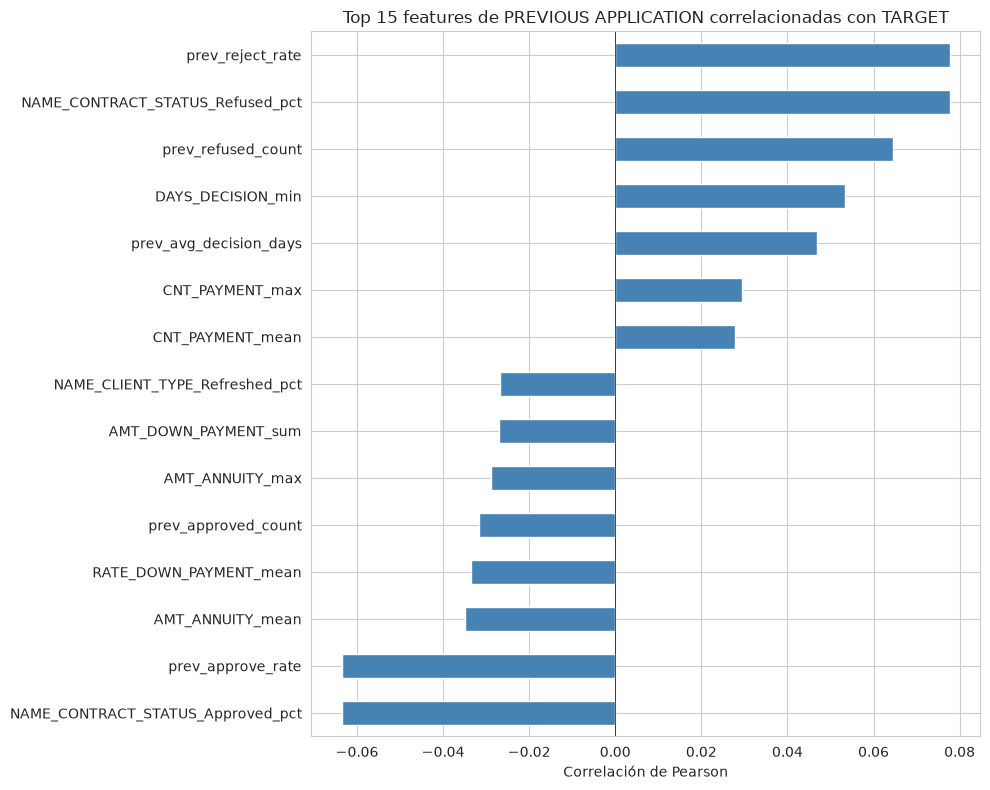

In [38]:
# Visualización: Top features correlacionadas con TARGET
top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)
top_features = top_corr.index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target[top_features].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 features de PREVIOUS APPLICATION correlacionadas con TARGET')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

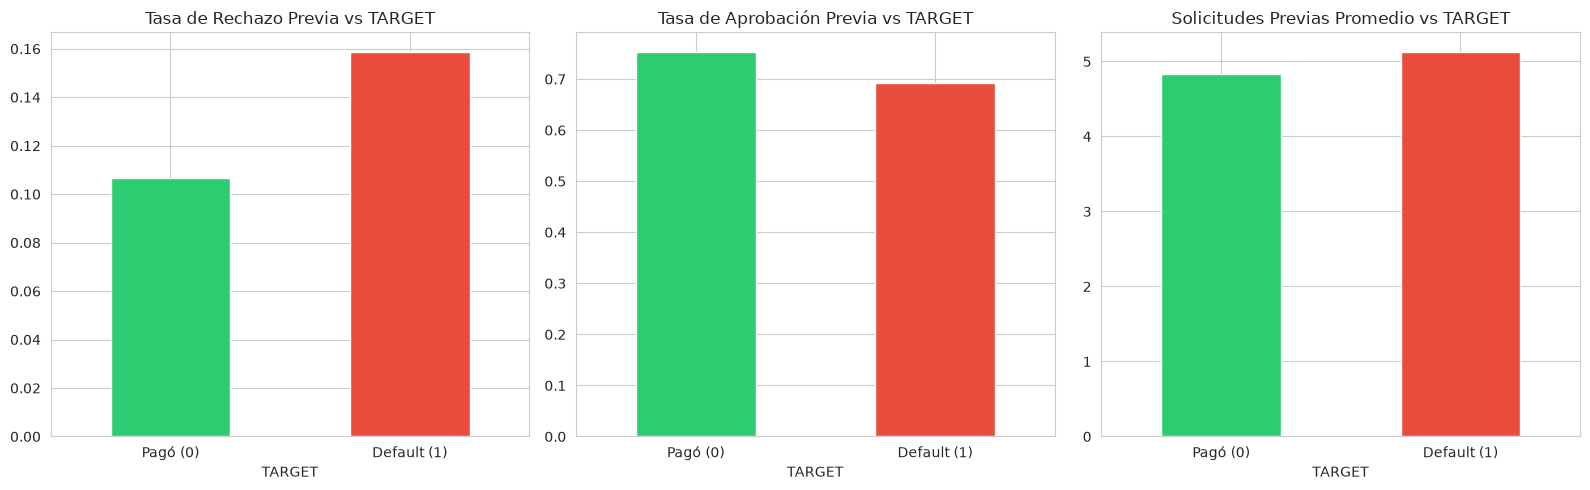

In [39]:
# Default rate por tasa de rechazo previo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tasa de rechazo vs TARGET
df.groupby(TARGET_COL)['prev_reject_rate'].mean().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Tasa de Rechazo Previa vs TARGET')
axes[0].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

# Tasa de aprobación vs TARGET
df.groupby(TARGET_COL)['prev_approve_rate'].mean().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Tasa de Aprobación Previa vs TARGET')
axes[1].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

# Número de solicitudes vs TARGET
df.groupby(TARGET_COL)['prev_total_applications'].mean().plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Solicitudes Previas Promedio vs TARGET')
axes[2].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()

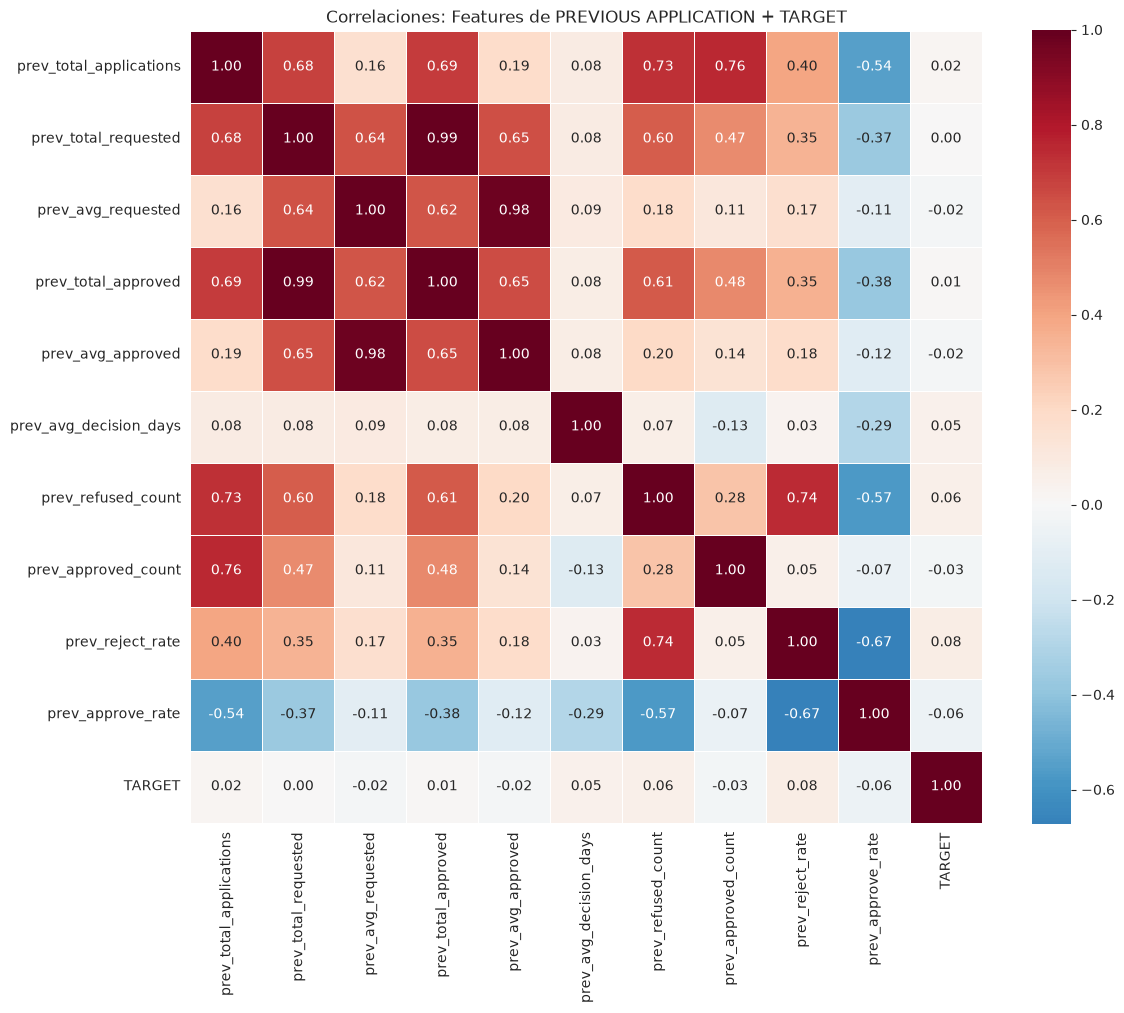

In [40]:
# Heatmap de correlaciones
prev_features = [c for c in new_cols if 'prev_' in c][:12]
prev_features.append(TARGET_COL)

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[prev_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones: Features de PREVIOUS APPLICATION + TARGET')
plt.tight_layout()
plt.show()

---
## 8. Impacto en la TARGET

In [41]:
# Clientes CON solicitud previa vs SIN
has_prev = df['prev_total_applications'].notna()

print('=== IMPACTO DE SOLICITUDES PREVIAS EN LA TARGET ===')
print()
print(f'Con solicitud previa:  {has_prev.sum():,} clientes')
print(f'  Default rate:        {df[has_prev][TARGET_COL].mean()*100:.2f}%')
print()
print(f'Sin solicitud previa:  {(~has_prev).sum():,} clientes')
print(f'  Default rate:        {df[~has_prev][TARGET_COL].mean()*100:.2f}%')

=== IMPACTO DE SOLICITUDES PREVIAS EN LA TARGET ===

Con solicitud previa:  291,057 clientes
  Default rate:        8.19%

Sin solicitud previa:  16,454 clientes
  Default rate:        5.96%


In [42]:
# Default rate por nivel de rechazo previo
df['reject_range'] = pd.cut(df['prev_reject_rate'].fillna(-0.1), 
                            bins=[-0.1, 0, 0.3, 0.6, 1.0],
                            labels=['Sin rechazos', 'Bajo (<30%)', 'Medio (30-60%)', 'Alto (>60%)'])

print('Default rate por tasa de rechazo previo:')
reject_default = df.groupby('reject_range')[TARGET_COL].agg(['mean', 'count'])
reject_default.columns = ['default_rate', 'n_clients']
reject_default['default_rate'] = reject_default['default_rate'] * 100
reject_default

Default rate por tasa de rechazo previo:


,default_rate,n_clients
reject_range,,
Sin rechazos,7.0732,190763
Bajo (<30%),8.3742,53462
Medio (30-60%),11.8632,39433
Alto (>60%),16.1779,7399


---
## 9. Guardar dataset enriquecido

In [43]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/application_train_prev.csv', index=False)
print(f'Guardado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Guardado: 307,511 filas x 152 columnas


---
## 10. Hallazgos y conclusiones
```

In [46]:
print('RESUMEN DEL EDA - Paso 3 (Previous Application)')
print('=' * 50)
print()
print('1. PREVIOUS APPLICATION:')
print(f'   - {prev.shape[0]:,} solicitudes previas registradas')
print(f'   - {prev["SK_ID_CURR"].nunique():,} clientes con solicitud previa')
print()
print('2. FEATURES GENERADAS:')
print(f'   - {len(new_cols)} nuevas features agregadas')
print()
print('3. TOP CORRELACIONES CON TARGET:')
top5 = corr_with_target.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = '+' if corr_with_target[feat] > 0 else '-'
    print(f'   - {feat}: {direction}{val:.4f}')
print()
print('4. IMPACTO:')
if has_prev.sum() > 0:
    rate_with = df[has_prev][TARGET_COL].mean()*100
    rate_without = df[~has_prev][TARGET_COL].mean()*100
    print(f'   - Default rate con solicitud previa: {rate_with:.2f}%')
    print(f'   - Default rate sin solicitud previa: {rate_without:.2f}%')
print()
print('5. RESUMEN DE EDA:')
print('   - 3 tablas exploradas: application, bureau, previous_application')
print('   - Próximo paso: Feature Engineering (04_feature_engineering.ipynb)')

RESUMEN DEL EDA - Paso 3 (Previous Application)

1. PREVIOUS APPLICATION:
   - 1,670,214 solicitudes previas registradas
   - 338,857 clientes con solicitud previa

2. FEATURES GENERADAS:
   - 29 nuevas features agregadas

3. TOP CORRELACIONES CON TARGET:
   - NAME_CONTRACT_STATUS_Refused_pct: +0.0777
   - prev_reject_rate: +0.0777
   - prev_refused_count: +0.0645
   - NAME_CONTRACT_STATUS_Approved_pct: -0.0635
   - prev_approve_rate: -0.0635

4. IMPACTO:
   - Default rate con solicitud previa: 8.19%
   - Default rate sin solicitud previa: 5.96%

5. RESUMEN DE EDA:
   - 3 tablas exploradas: application, bureau, previous_application
   - Próximo paso: Feature Engineering (04_feature_engineering.ipynb)
